<a href="https://colab.research.google.com/github/pvgbabu/AWS-Sage-Maker/blob/master/Labs/Lab_3_Improving_RAG_Benefits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: RAG Improvements

In this section, we will use our metric-driven experimentation to improve our RAG system. We will do so by:
1. Implementing LlamaParse
2. Implementing hybrid search
3. Exploring the input prompts for llama-index RAG implementations.

**Dataset: CalHR employee benefits.** 20 documents, 255 chunks at 384/96.

_____
## Imports + Downloads

The retrieval in this lab runs entirely inside this notebook. Two routes over the same
20 documents:

- **dense**, the vector search you built in Lab 2
- **keyword**, BM25, a classic ranking function over the words themselves

and then a **hybrid** that fuses the two. Nothing is hosted, so nothing can be rate limited
or suspended for the whole room at once.

The corpus arrives pre-parsed and pre-embedded as a single file, because the parsing step
takes about a minute per document.


In [ ]:
# Every version here is pinned, including the llama-index satellites. An unpinned
# dependency is a bet that nothing upstream changes between now and the moment you run
# this, and that bet is how a notebook that worked last week stops working today.
%pip install -q \
  litellm==1.102.0 "openai>=2.20.0,<3.0.0" \
  llama-index==0.14.24 llama-index-readers-file==0.7.0 fonttools==4.65.0 \
  llama-index-vector-stores-chroma==0.6.0 \
  llama-index-embeddings-litellm==0.6.0 llama-index-llms-openrouter==0.6.0 \
  llama-index-retrievers-bm25==0.8.0 bm25s PyStemmer \
  chromadb==1.5.9 pandas==2.2.3 pyarrow nest_asyncio


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.4/678.4 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.3/278.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:

import os
import asyncio
import logging
import zipfile
import pandas as pd

import Stemmer
import chromadb

from llama_index.core import VectorStoreIndex, Settings
from llama_index.core.schema import TextNode
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.embeddings.litellm import LiteLLMEmbedding

# llama_index.llms.openai.OpenAI validates model names against its own table of OpenAI
# models and raises on an id like "openai/gpt-4.1-mini", even with a correct api_base.
# OpenRouter (which extends OpenAILike) does not.
from llama_index.llms.openrouter import OpenRouter

# bm25s logs every step of building its index at DEBUG, which fills the cell with lines
# nobody in the room needs to read. The retriever is unaffected.
logging.getLogger("bm25s").setLevel(logging.WARNING)


In [ ]:
# Every setting this lab shares with the other labs comes from one file in the public repo.
# Change a value there, not here. Retrieval results are only comparable when the chunk size,
# the embedding model and the judge are held still, and this is what holds them still.
import json, urllib.request

DATASET = 'calhr'   # one notebook per dataset is stamped out at build time; no picker here

CONFIG_URL = "https://raw.githubusercontent.com/ndecavel/tdwi-workshop-labs/main/data/dataset_config.json"
urllib.request.urlretrieve(CONFIG_URL, "/content/dataset_config.json")
CFG = json.load(open("/content/dataset_config.json"))
SHARED, DS = CFG['shared'], CFG['datasets'][DATASET]
print(f"dataset={DATASET} ({DS['label']}), chunking={DS['chunk_size']}/{DS['chunk_overlap']}")

urllib.request.urlretrieve(DS['golden_url'], "/content/Golden_Test_Data_DeepEval.csv")
golden_df = pd.read_csv('/content/Golden_Test_Data_DeepEval.csv')
golden_df = golden_df.drop(columns=[c for c in golden_df.columns if c.startswith('Unnamed')])
golden_df = golden_df.rename(columns={'input':'question', 'expected_output':'ground_truth'})

In [ ]:
GPT_MODEL   = SHARED['generator_model']   # generator, non-reasoning on purpose (see below)
JUDGE_MODEL = SHARED['judge_model']       # the evaluator, held fixed across every engine
EMBED_MODEL = SHARED['embed_model']

# The corpus below was embedded with EMBED_MODEL. Query-time embeddings must use the same
# model or dense retrieval quietly gets worse instead of failing.
CORPUS_URL = DS['corpus_url']
assert CORPUS_URL, (
    f"dataset_config.json carries no corpus_url for {DATASET!r} yet. The pre-parsed "
    "corpus has to be published as a release asset before this notebook can run.")

# How many golden questions to evaluate. Each one costs a query and 3 judge calls per
# engine, so 15 questions over 3 engines is ~180 model calls per attendee.
SAMPLE_SIZE = SHARED['lab_sample_size']

# Ceiling on concurrent in-flight calls, so one attendee cannot fire the whole batch at once.
MAX_CONCURRENCY = SHARED['max_concurrency']

TOP_K = SHARED['similarity_top_k']
CONTEXT_WINDOW = SHARED['context_window']
MAX_TOKENS = SHARED['max_tokens']         # None: no ceiling sent at all. See below.

# context_window and max_tokens are both set explicitly, and both matter.
#
# llama-index's defaults are context_window=3900 and max_tokens=256. They are not
# OpenRouter's and not the model's: they are llama-index-wide constants
# (DEFAULT_CONTEXT_WINDOW, DEFAULT_NUM_OUTPUTS in llama_index/core/constants.py) that date
# from the GPT-3 era, when 4,097 tokens was the whole window. Nothing updates them per model.
#
# Both defaults broke this lab silently:
#   * Five retrieved chunks are about 4,200 tokens, over the 3,900 window, so llama-index
#     split the context and answered over several "refine" passes. Slower, worse, no warning.
#     Measured: 1.7 generator calls per question instead of 1, and the judge did it too.
#   * max_tokens is the budget for EVERYTHING the model emits, and on a reasoning model that
#     includes reasoning tokens you never see. gpt-5-mini spent all 256 thinking and returned
#     llama-index's literal "Empty Response", which then scored zero on faithfulness and
#     answer relevancy and looked like a retrieval failure.
#
# MAX_TOKENS is None here, which means the parameter is left out of the request entirely and
# the model generates up to its own limit. Note the trap: passing None and omitting the
# argument are opposites in this class. Omit it and you inherit DEFAULT_NUM_OUTPUTS = 256,
# the setting that caused the failure above. None removes the ceiling; leaving it out
# reinstates the worst possible one.
#
# A ceiling is also not a cost control: you are billed for tokens actually generated, not for
# the cap. Raising max_tokens WITHOUT raising context_window fails outright, since llama-index
# computes available context as window minus max_tokens:
#   ValueError: Calculated available context size -300 was not non-negative.

In [ ]:
# The day's keys come from the workshop hub, so there is nothing to paste and
# nothing to mistype. Rerun this cell any time a key stops working.
# One key covers chat, embeddings and the judge. Nothing else needs credentials: the
# corpus is a file you download, and the indexes are built here in the notebook.
import json, os, urllib.error, urllib.request

WORKSHOP_HUB = "https://tdwi-workshop-hub.vercel.app"

def load_workshop_keys(hub=WORKSHOP_HUB):
    """Ask the hub for the day's keys and load them into this session."""
    request = urllib.request.Request(
        f"{hub}/api/env", data=b"{}", headers={"content-type": "application/json"})
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            payload = json.load(response)
    except urllib.error.HTTPError as error:
        if error.code == 403:
            raise SystemExit(
                "The workshop is not running right now, so the hub is not handing out "
                "keys. If the class is in session, raise your hand and find Nicolas or "
                "Kierra.") from None
        raise SystemExit(
            f"The hub could not hand out a key (error {error.code}). Run this cell again, "
            "and raise your hand if it keeps failing.") from None
    except urllib.error.URLError:
        raise SystemExit(
            "Could not reach the workshop hub. Check that you are on the conference wifi, "
            "then run this cell again.") from None
    os.environ.update(payload)
    return sorted(payload)

print("Loaded from the hub:", ", ".join(load_workshop_keys()))


# No product catalogue here: the documents are the catalogue. Where each PDF came from,
# and the five that CalHR publishes only as non-downloadable flipbooks, are recorded in
# data/calhr/MANIFEST.md in the workshop repo.


____

In [ ]:
# The 20 documents, as published. Six handbooks hold 90% of the text; the 14 flyers are
# two pages each and are kept because they give the file_name metadata something to
# discriminate on during retrieval.
catalog = pd.DataFrame(
    [("2026 CoBen Handbook", "handbook", 13),
     ("2026 Dental Active Handbook", "handbook", 27),
     ("2026 Dental Retiree Handbook", "handbook", 27),
     ("2026 FlexElect Handbook", "handbook", 26),
     ("2026 Long-Term Disability Benefits Guide", "handbook", 25),
     ("2027 Benefit Summary for Active State Employees", "handbook", 39),
     ("2026 Cash Options Flyer", "flyer", 2),
     ("2026 Dependent Care Reimbursement Account Flyer", "flyer", 2),
     ("2026 EAP Core Flyer", "flyer", 3),
     ("2026 EAP Digital Emotional Wellbeing", "flyer", 2),
     ("2026 EAP Financial Wellbeing", "flyer", 2),
     ("2026 EAP Legal Services", "flyer", 2),
     ("2026 EAP LifeMart Discount Center", "flyer", 2),
     ("2026 EAP Manager Support", "flyer", 2),
     ("2026 EAP Website Flyer", "flyer", 2),
     ("2026 EAP Wellbeing Coaching", "flyer", 2),
     ("2026 EAP Work Life Services", "flyer", 2),
     ("2026 FlexElect Reimbursement Account Flyer", "flyer", 2),
     ("2026 Long-Term Disability Flyer", "flyer", 2),
     ("2026 Medical Reimbursement Account Flyer", "flyer", 2)],
    columns=["title", "kind", "pages"])

print(catalog.groupby("kind")["pages"].agg(["count", "sum"]))
catalog.head(6)

The six handbooks above are where nearly all of the retrievable text lives, and they are also where the hard questions come from. Note the two dental handbooks. About half of the retiree handbook's text appears word for word in the active one, which makes them genuinely confusable and gives the "retrieved the wrong document" failure a real example rather than a staged one.

In [ ]:
# Everything routes through OpenRouter, so one key covers the generator, the judge and
# the embeddings.
llm = OpenRouter(model=GPT_MODEL, api_key=os.environ["OPENROUTER_API_KEY"],
                 context_window=CONTEXT_WINDOW, max_tokens=MAX_TOKENS)
embed_model = LiteLLMEmbedding(model_name=EMBED_MODEL, embed_batch_size=100)

Settings.llm = llm
Settings.embed_model = embed_model


In [ ]:
### This is how the corpus you are about to download was produced. It is commented out
### because LlamaParse takes roughly a minute per document, and there are 20 of them.
### The parsed result is published as a release asset, so nobody pays that cost twice.
###
### Note `output_tables_as_HTML=True`. That is why the raw parse came back with <table>
### markup rather than markdown, which is rewritten before the corpus ships. See
### scripts/build_improved_nodes.py in the workshop repo.
# import nest_asyncio
# nest_asyncio.apply()

# parser = LlamaParse(
#     api_key=### Here is where you would input your Llama Parse API Key,
#     result_type="markdown",
#     num_workers=4,
#     parse_mode="parse_page_with_agent",
#     model="openai-gpt-5-mini",
#     outlined_table_extraction=True,
#     output_tables_as_HTML=True,
#     verbose=True
# )

# import glob
# for file in glob.glob(f"{DOCS_FOLDER_PATH}/*.pdf"):
#   documents[file] = await parser.aparse(file)


### Read more about Llama Parse here! https://www.llamaindex.ai/blog/launching-the-first-genai-native-document-parsing-platform

LlamaParse, developed by LlamaIndex, is the first GenAI-native document parsing platform, designed to harness the power of large language models (LLMs) for advanced document processing. Since its public release, it has attracted over 2,000 users and parsed over a million pages. Key features include:

- **GenAI-powered parsing instructions**: Users can give simple, natural-language directives to the parser, improving accuracy and efficiency for various document types, including rich tables, translated manga, and complex mathematical equations. This feature also enables tasks like sentiment analysis, language simplification, and translation.

- **JSON mode**: Provides a detailed programmatic format for precise parsing requirements. Outputs include:
  - Document structure
  - Marked tables, text, and headings
  - Images with metadata
  - CSV and JSON formats for tables

LlamaParse supports a wide range of document types beyond PDFs, such as Microsoft Word, PowerPoint, Rich Text Format, Apple Pages, and ePub books.

### Understanding hybrid search with RFR:

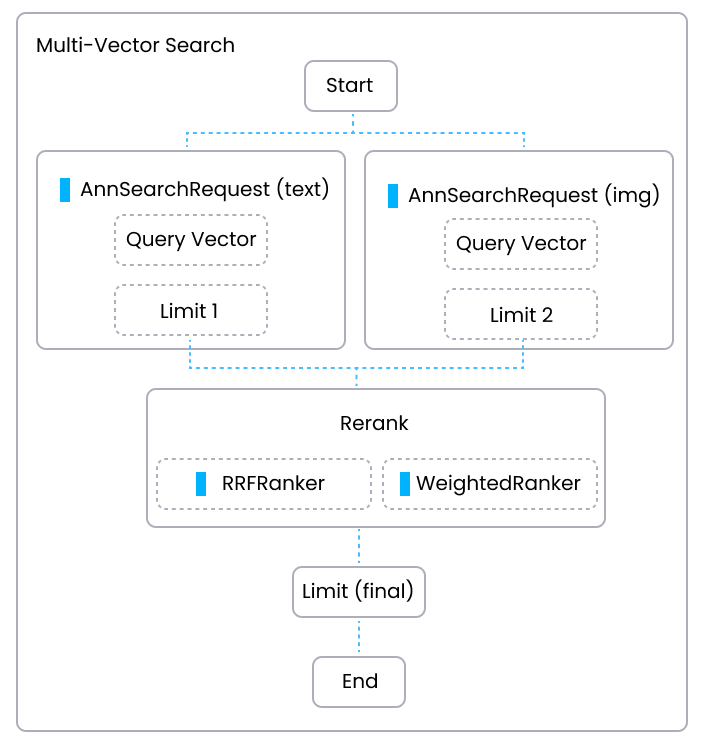

Two ways to combine the results of a dense (vector) search and a keyword search:

#### Weighted scoring
Give each retrieval route a weight and add the weighted scores. This suits the case where
you know one route matters more than another, for example when a text description should
count for more than a colour histogram. It needs the two routes' scores to be comparable,
which is the hard part: a cosine similarity and a BM25 score are not on the same scale.

#### Reciprocal Rank Fusion (RRF)
RRF ignores the scores entirely and uses only the **rank** each route assigned. A document
ranked *r* by a route contributes `1 / (k + r)`, and a document's final score is the sum of
that across routes. Because only ranks are used, the two routes never have to agree on what
a score means, which is why RRF is the usual default when there is no clear reason to
prefer one route.

`k` damps the advantage of the very top ranks; a larger `k` flattens the curve. The constant
is conventionally 60, which is what the LlamaIndex `QueryFusionRetriever` you are about to
build uses by default. Hosted vector databases implement the same algorithm; here it runs
in the notebook, so you can read it.


In [ ]:
## 1. Download the pre-parsed corpus and load it into a local Chroma collection.
## Nothing is embedded here: the vectors ship with the file.
import urllib.request

urllib.request.urlretrieve(CORPUS_URL, "/content/corpus.parquet")
corpus = pd.read_parquet("/content/corpus.parquet")
print(f"{len(corpus)} chunks over {corpus.file_name.nunique()} documents, "
      f"{len(corpus.embedding.iloc[0])}-dimensional embeddings")

# Contextual retrieval ships as two extra columns, built once and published with the corpus.
# If this
# corpus predates them the last section of the lab skips itself and says so.
HAS_CONTEXT = ('embedding_contextual' in corpus.columns
               and corpus['embedding_contextual'].notna().all()
               and corpus.get('context', pd.Series(dtype=str)).fillna('').str.len().gt(0).any())
print(f"contextual vectors present: {HAS_CONTEXT}")

nodes = [
    TextNode(
        id_=row.id,
        text=row.text,
        embedding=list(row.embedding),
        metadata={"file_name": row.file_name, "page_label": row.page_label},
    )
    for row in corpus.itertuples()
]

chroma_client = chromadb.EphemeralClient()
chroma_collection = chroma_client.get_or_create_collection(
    name="improved_vector_store",
    configuration={"hnsw": {"space": "cosine"}},
)
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)

# Chroma refuses a single .add() over 5461 records.
BATCH = 4000
for i in range(0, len(nodes), BATCH):
    vector_store.add(nodes[i:i + BATCH])

print(f"Loaded {chroma_collection.count()} chunks into Chroma with no embedding calls")

In [ ]:
### The corpus file was built from the LlamaParse output by scripts/build_improved_nodes.py
### in the workshop repo, run with --from-parsed. All 20 documents went through LlamaParse
### at tier=agentic with the version pinned to a date, so the parse can be reproduced.
### 255 chunks at 384/96, every chunk matched back to its page, and 223 of them carrying
### the page number printed on the page itself.
###
### 384/96, rather than the 1024/200 this workshop uses for the paint corpus, is deliberate.
### This corpus is a sixth the size. At 1024/200 it splits into about 100 chunks, so a
### top-5 query would return 5% of everything there is, and dense retrieval would find the
### right chunk more or less by accident.

In [ ]:
index = VectorStoreIndex.from_vector_store(vector_store, embed_model=Settings.embed_model)


____
### Now that we've made a few changes, let us experiment with how this may improve our RAG system.

In [ ]:
## 2. Build the three retrievers we are comparing.

# a) naive: dense vectors only, the Lab 2 approach
dense_retriever = index.as_retriever(similarity_top_k=TOP_K)

# b) keyword: BM25, running in this notebook over the same nodes. No database involved.
bm25_retriever = BM25Retriever.from_defaults(
    nodes=nodes,
    similarity_top_k=TOP_K,
    stemmer=Stemmer.Stemmer("english"),
    language="english",
)

# c) hybrid: fuse the two by reciprocal rank.
# num_queries=1 stops the retriever generating extra query variations with the LLM, which
# would add a model call per question and confound the comparison.
hybrid_retriever = QueryFusionRetriever(
    [dense_retriever, bm25_retriever],
    mode="reciprocal_rerank",
    num_queries=1,
    similarity_top_k=TOP_K,
    use_async=True,
)

naive_query_engine = RetrieverQueryEngine.from_args(dense_retriever, llm=llm)
full_text_search_engine = RetrieverQueryEngine.from_args(bm25_retriever, llm=llm)
hybrid_query_engine = RetrieverQueryEngine.from_args(hybrid_retriever, llm=llm)

# synthetic_input_quality is a score the question generator assigned itself. Keeping only
# the 1.0 rows drops questions that were malformed before anyone tried to answer them.
sample_test_df = golden_df[golden_df['synthetic_input_quality'] == SHARED['quality_filter']]
sample_test_df = sample_test_df.sample(SAMPLE_SIZE, random_state=SHARED['random_state'])
print(f"Evaluating {len(sample_test_df)} questions against 3 engines (a 4th is added at the end if the corpus has contextual vectors)")


In [ ]:
import tqdm
from tqdm.asyncio import tqdm_asyncio
import nest_asyncio
import asyncio

nest_asyncio.apply()

from llama_index.core import (
    VectorStoreIndex,
    SimpleDirectoryReader,
    Response,
)
from llama_index.core.evaluation import FaithfulnessEvaluator, ContextRelevancyEvaluator, AnswerRelevancyEvaluator
from llama_index.core.evaluation import EvaluationResult

pd.set_option("display.max_colwidth", 0)

async def evaluate_query_engine(query_engine, questions):
    print(f"Evaluating query engine on {len(questions)} questions.")

    # The judge reads the retrieved context too, so it needs the same real window.
    llm_model = OpenRouter(model=JUDGE_MODEL, api_key=os.environ["OPENROUTER_API_KEY"],
                           context_window=CONTEXT_WINDOW, max_tokens=MAX_TOKENS)

    faithful_eval = FaithfulnessEvaluator(llm=llm_model)
    context_relevancy_eval = ContextRelevancyEvaluator(llm=llm_model)
    answer_relevancy_eval = AnswerRelevancyEvaluator(llm=llm_model)

    # 1. Run Queries in parallel, but not all at once.
    # Without the semaphore one attendee opens SAMPLE_SIZE connections simultaneously, and
    # 80 attendees doing that is what trips OpenRouter's per-account rate limit.
    limit = asyncio.Semaphore(MAX_CONCURRENCY)

    async def _bounded(coro_fn):
        async with limit:
            return await coro_fn()

    c = [_bounded(lambda q=q: query_engine.aquery(q)) for q in questions]
    results = await tqdm_asyncio.gather(*c, desc="Running Queries")

    print("Finished Running Queries, now starting evals")

    evals = {}

    # 2. Run each evaluator type sequentially, but parallelize within each type
    for eval_name, eval_obj in [("faithful", faithful_eval),
                                ("context_relevancy", context_relevancy_eval),
                                ('answer_relevancy', answer_relevancy_eval)]:

        print(f"Running eval: {eval_name}")
        eval_tasks = []

        # Create all tasks for this evaluator type
        for question, r in zip(questions, results):
            contexts = [node.get_content() for node in r.source_nodes]

            if eval_name == 'faithful':
                task = eval_obj.aevaluate(response=r.response, query=question, contexts=contexts)
            elif eval_name == 'answer_relevancy':
                task = eval_obj.aevaluate(query=question, response=r.response)
            elif eval_name == 'context_relevancy':
                task = eval_obj.aevaluate(query=question, contexts=contexts)

            eval_tasks.append(task)

        # Run all tasks for this evaluator in parallel, under the same ceiling
        bounded_tasks = [_bounded(lambda t=t: t) for t in eval_tasks]
        evals[eval_name] = await tqdm_asyncio.gather(*bounded_tasks, desc=f"Eval: {eval_name}")

    return evals, results

# Run naive evals
naive_evals, naive_results = await evaluate_query_engine(naive_query_engine, sample_test_df['question'])

# Run full text search evals
full_text_evals, full_text_results = await evaluate_query_engine(full_text_search_engine, sample_test_df['question'])

# Run hybrid evals
hybrid_evals, hybrid_results = await evaluate_query_engine(hybrid_query_engine, sample_test_df['question'])

In [ ]:
### Run the following cell to visualize the results and identify which approach performed better!
import numpy as np

# A judge reply the metric could not parse comes back with score None. One of those is
# enough to crash the longest step of this lab on an arithmetic error, so None is dropped
# from the aggregates and shown as NaN per question rather than being averaged in.
def scores_of(results):
    kept = [res.score for res in results if res.score is not None]
    return kept or [np.nan]

def score_of(res):
    return np.nan if res.score is None else res.score

def compare_eval_results_three_way(naive_evals, full_text_evals, hybrid_evals):
    """Compare naive, full text, and hybrid results in a tabular format"""

    # Aggregate comparison across all metrics
    print("=" * 100)
    print("AGGREGATE COMPARISON - ALL APPROACHES")
    print("=" * 100)

    comparison_data = []
    for metric_name in naive_evals.keys():
        naive_scores = scores_of(naive_evals[metric_name])
        full_text_scores = scores_of(full_text_evals[metric_name])
        hybrid_scores = scores_of(hybrid_evals[metric_name])

        comparison_data.append({
            'Metric': metric_name,
            'Naive Mean': np.round(np.mean(naive_scores), 3),
            'Full Text Mean': np.round(np.mean(full_text_scores), 3),
            'Hybrid Mean': np.round(np.mean(hybrid_scores), 3),
            'Best Approach': max([
                ('Naive', np.mean(naive_scores)),
                ('Full Text', np.mean(full_text_scores)),
                ('Hybrid', np.mean(hybrid_scores))
            ], key=lambda x: x[1])[0],
            'Naive→FT Δ': np.round(np.mean(full_text_scores) - np.mean(naive_scores), 3),
            'Naive→Hybrid Δ': np.round(np.mean(hybrid_scores) - np.mean(naive_scores), 3),
        })

    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df)

    # Per-question detailed comparison
    print("\n" + "=" * 100)
    print("PER-QUESTION COMPARISON")
    print("=" * 100)

    for metric_name in naive_evals.keys():
        print(f"\n{metric_name.upper()}")
        print("-" * 100)

        naive_results = naive_evals[metric_name]
        full_text_results = full_text_evals[metric_name]
        hybrid_results = hybrid_evals[metric_name]

        question_data = []
        for i, (naive_res, ft_res, hybrid_res) in enumerate(zip(naive_results, full_text_results, hybrid_results)):
            naive_score = np.round(score_of(naive_res), 3)
            ft_score = np.round(score_of(ft_res), 3)
            hybrid_score = np.round(score_of(hybrid_res), 3)

            # Determine winner
            max_score = max(naive_score, ft_score, hybrid_score)
            if hybrid_score == max_score:
                winner = '🟢 Hybrid'
            elif ft_score == max_score:
                winner = '🔵 Full Text'
            else:
                winner = '🔴 Naive'

            # Handle ties
            if sum([s == max_score for s in [naive_score, ft_score, hybrid_score]]) > 1:
                winner = '⚪ Tie'

            question_data.append({
                'Q #': i + 1,
                'Naive': naive_score,
                'Full Text': ft_score,
                'Hybrid': hybrid_score,
                'Winner': winner,
                'Range': np.round(max_score - min(naive_score, ft_score, hybrid_score), 3)
            })

        question_df = pd.DataFrame(question_data)
        display(question_df)

        # Show win/loss summary
        hybrid_wins = sum(1 for d in question_data if '🟢' in d['Winner'])
        ft_wins = sum(1 for d in question_data if '🔵' in d['Winner'])
        naive_wins = sum(1 for d in question_data if '🔴' in d['Winner'])
        ties = sum(1 for d in question_data if '⚪' in d['Winner'])

        print(f"\nSummary: Hybrid: {hybrid_wins} | Full Text: {ft_wins} | Naive: {naive_wins} | Ties: {ties}")

    # Overall verdict
    print("\n" + "=" * 100)
    print("OVERALL VERDICT")
    print("=" * 100)

    # Calculate total scores across all metrics
    total_naive = sum([np.mean(scores_of(naive_evals[metric]))
                       for metric in naive_evals.keys()])
    total_ft = sum([np.mean(scores_of(full_text_evals[metric]))
                    for metric in full_text_evals.keys()])
    total_hybrid = sum([np.mean(scores_of(hybrid_evals[metric]))
                        for metric in hybrid_evals.keys()])

    rankings = sorted([
        ('Naive', total_naive),
        ('Full Text', total_ft),
        ('Hybrid', total_hybrid)
    ], key=lambda x: x[1], reverse=True)

    print(f"🥇 1st: {rankings[0][0]} (score: {np.round(rankings[0][1], 3)})")
    print(f"🥈 2nd: {rankings[1][0]} (score: {np.round(rankings[1][1], 3)})")
    print(f"🥉 3rd: {rankings[2][0]} (score: {np.round(rankings[2][1], 3)})")

    improvement_ft = total_ft - total_naive
    improvement_hybrid = total_hybrid - total_naive

    print(f"\nImprovements over Naive:")
    print(f"  Full Text:  {'+' if improvement_ft > 0 else ''}{np.round(improvement_ft, 3)}")
    print(f"  Hybrid:     {'+' if improvement_hybrid > 0 else ''}{np.round(improvement_hybrid, 3)}")

# Usage
compare_eval_results_three_way(naive_evals, full_text_evals, hybrid_evals)

In [ ]:
def compare_all_approaches(naive_evals, full_text_evals, hybrid_evals):
    """Simplified three-way comparison"""

    all_approaches = {
        'Naive': naive_evals,
        'Full Text': full_text_evals,
        'Hybrid': hybrid_evals
    }

    # Summary table
    summary_data = []
    for metric_name in naive_evals.keys():
        row = {'Metric': metric_name}
        for approach_name, evals in all_approaches.items():
            scores = scores_of(evals[metric_name])
            row[f'{approach_name} Mean'] = np.round(np.mean(scores), 3)
        summary_data.append(row)

    summary_df = pd.DataFrame(summary_data)

    # Add "Best" column
    approach_cols = [col for col in summary_df.columns if 'Mean' in col]
    summary_df['Best'] = summary_df[approach_cols].idxmax(axis=1).str.replace(' Mean', '')

    print("=" * 80)
    print("SUMMARY COMPARISON")
    print("=" * 80)
    display(summary_df)

    # Calculate total scores across all metrics
    total_naive = sum([np.mean(scores_of(naive_evals[metric]))
                       for metric in naive_evals.keys()])
    total_ft = sum([np.mean(scores_of(full_text_evals[metric]))
                    for metric in full_text_evals.keys()])
    total_hybrid = sum([np.mean(scores_of(hybrid_evals[metric]))
                        for metric in hybrid_evals.keys()])

    rankings = sorted([
        ('Naive', total_naive),
        ('Full Text', total_ft),
        ('Hybrid', total_hybrid)
    ], key=lambda x: x[1], reverse=True)

    print("\n" + "=" * 80)
    print("OVERALL VERDICT")
    print("=" * 80)
    print(f"🥇 1st: {rankings[0][0]} (score: {np.round(rankings[0][1], 3)})")
    print(f"🥈 2nd: {rankings[1][0]} (score: {np.round(rankings[1][1], 3)})")
    print(f"🥉 3rd: {rankings[2][0]} (score: {np.round(rankings[2][1], 3)})")

    improvement_ft = total_ft - total_naive
    improvement_hybrid = total_hybrid - total_naive

    print(f"\nImprovements over Naive:")
    print(f"  Full Text:  {'+' if improvement_ft > 0 else ''}{np.round(improvement_ft, 3)}")
    print(f"  Hybrid:     {'+' if improvement_hybrid > 0 else ''}{np.round(improvement_hybrid, 3)}")

# Usage
compare_all_approaches(naive_evals, full_text_evals, hybrid_evals)

____
### What the same comparison measured on the authoring side, and why judge scores are the wrong instrument here

Run over 30 golden questions with the judge held fixed at `google/gemini-2.5-flash`, the aggregate scores on this corpus do not separate the engines:

| engine | aggregate (max 3.0) |
|---|---|
| naive | 2.940 |
| hybrid | 2.913 |

Read that as a tie, not as a win for naive. Two of the three metrics are saturated. Faithfulness sits at a perfect score on 98.9% of cells and answer relevancy on 96.7%, and 63% of the questions score full marks for every engine. An apparent sample of 30 is an effective sample of about 11.

Measuring retrieval directly, with no judge and no generation, does separate them:

| engine | hit@5 | MRR | doc@5 |
|---|---|---|---|
| naive | 86.7% | 0.581 | 100% |
| full text | 86.7% | 0.621 | 100% |
| **hybrid** | 86.7% | **0.650** | 96.7% |

All three engines find the right passage equally often. Hybrid finds it sooner. That ordering, hybrid above full text above naive, is what this lab claims, and it holds on this corpus. The judge-based numbers simply cannot see it.

So the honest reading of your own results above is: if the three aggregates land within a few hundredths of each other, that is the expected outcome and it is a fact about the metric, not about the retriever. A saturated measurement is not evidence that nothing changed. On the paint corpus, where retrieval is harder, the same comparison does move: hybrid 2.900 against naive 2.825, with the whole margin in context relevancy.

## Prompts!

One thing we haven't explored yet with RAG is the specific prompts being used behind the scenes. How does it combine our question with the context? We can answer this by viewing the prompts of our query engine! This is where we can easily change these prompts if we would like to, but note that you would want to make sure certain mappings for the *context_str* and the *query_str* are consistent.






In [ ]:

from IPython.display import Markdown, display

# define prompt viewing function
def display_prompt_dict(prompts_dict):
    for k, p in prompts_dict.items():
        text_md = f"**Prompt Key**: {k}" f"**Text:** "
        display(Markdown(text_md))
        print(p.get_template())
        display(Markdown(""))

prompts_dict = hybrid_query_engine.get_prompts()
display_prompt_dict(prompts_dict)

____

## 4. Contextual retrieval

Everything above tried to improve retrieval by changing **how we search**: dense vectors, then
keywords, then a fusion of the two. Contextual retrieval changes **what we index** instead.

The problem it addresses is structural. Chunking destroys context. A chunk that reads

> The rate increased by 3% over the previous period.

is useless to a retriever, because nothing in it says which rate, which period, or which
document it came from. Embed that sentence and it lands nowhere near a query that names the
plan it belongs to. BM25 cannot rescue it either: the words a searcher would type are the
exact words the chunk is missing.

Anthropic's fix, published as [Contextual Retrieval](https://www.anthropic.com/news/contextual-retrieval)
in September 2024, is blunt and effective. Before indexing, show a model the **whole document**
alongside each chunk and ask for one or two sentences situating that chunk inside it. Prepend
the result to the chunk, then embed and index *that*.

So the chunk above becomes something like

> This chunk is from the 2026 dental plan handbook's premium schedule section, covering
> employee-only coverage under the basic plan.
>
> The rate increased by 3% over the previous period.

The reported result on their benchmark: top-20 retrieval failure rate fell from 5.7% to 3.7%
with contextual embeddings, to 2.9% when the BM25 index is built over the contextualised text
too, and to 1.9% with a reranker on top. Treat those as a direction rather than a promise:
they were measured on their corpus, not yours, which is exactly why we are about to measure
it on ours.

### Why you are not waiting for this to run

One LLM call per chunk, each carrying its chunk's entire document, is far too slow to do live.
It was done once, ahead of today, and the result ships inside the corpus file you already
downloaded, in two extra columns: `context` and `embedding_contextual`. You pay nothing for it
here, in the same way you did not pay to run LlamaParse over 20 documents.

### One honest caveat about what follows

The engine below hands the generator the context line **as well as** the chunk, because that is
what a deployed system would do. It also means that if the score goes up, you cannot tell how
much came from retrieving better chunks and how much came from the generator simply having more
information in front of it. Separating those takes a fourth variant that strips the context
before synthesis. Worth knowing the comparison is not pure, and worth not overclaiming from it.

In [ ]:
## Build the contextual engine over the vectors that shipped with the corpus.

if not HAS_CONTEXT:
    print("This corpus has no contextual vectors, so this section is skipped.")
    print("Nothing to do here: ask the instructor if you want to see it run.")
else:
    # This join has to match the one the vectors were built with, character for character.
    # Embed one string and retrieve over another and you get silent, plausible nonsense.
    def contextualised_text(context, text):
        return f"{context}\n\n{text}" if context else text

    print("Three examples of what the model wrote, so you can judge it yourself:\n")
    for row in corpus[corpus.context.str.len() > 0].head(3).itertuples():
        print(f"[{row.file_name} p{row.page_label}]")
        print(f"  context: {row.context}")
        print(f"  chunk:   {row.text[:140].strip()}...\n")

    ctx_nodes = [
        TextNode(
            id_=f"ctx-{row.id}",
            text=contextualised_text(row.context, row.text),
            embedding=list(row.embedding_contextual),
            metadata={"file_name": row.file_name, "page_label": row.page_label},
        )
        for row in corpus.itertuples()
    ]

    ctx_collection = chroma_client.get_or_create_collection(
        name="contextual_vector_store",
        configuration={"hnsw": {"space": "cosine"}},
    )
    ctx_store = ChromaVectorStore(chroma_collection=ctx_collection)
    for i in range(0, len(ctx_nodes), BATCH):
        ctx_store.add(ctx_nodes[i:i + BATCH])
    ctx_index = VectorStoreIndex.from_vector_store(ctx_store, embed_model=Settings.embed_model)

    # Same two retrievers as before, same fusion, over the contextualised text. The only
    # thing that changed is what got indexed, which is the whole point of the technique.
    ctx_dense_retriever = ctx_index.as_retriever(similarity_top_k=TOP_K)
    ctx_bm25_retriever = BM25Retriever.from_defaults(
        nodes=ctx_nodes,
        similarity_top_k=TOP_K,
        stemmer=Stemmer.Stemmer("english"),
        language="english",
    )
    ctx_hybrid_retriever = QueryFusionRetriever(
        [ctx_dense_retriever, ctx_bm25_retriever],
        mode="reciprocal_rerank",
        num_queries=1,
        similarity_top_k=TOP_K,
        use_async=True,
    )
    contextual_query_engine = RetrieverQueryEngine.from_args(ctx_hybrid_retriever, llm=llm)
    print(f"Contextual hybrid engine ready over {ctx_collection.count()} chunks")

In [ ]:
## Evaluate it on the same questions, and compare against plain hybrid.
## This is ~60 more model calls: 15 queries plus 45 judge calls.

if not HAS_CONTEXT:
    print("Skipped: no contextual vectors in this corpus.")
else:
    contextual_evals, contextual_results = await evaluate_query_engine(
        contextual_query_engine, sample_test_df['question'])

    rows = []
    for metric in hybrid_evals.keys():
        plain = np.mean([r.score for r in hybrid_evals[metric] if r.score is not None])
        ctx = np.mean([r.score for r in contextual_evals[metric] if r.score is not None])
        rows.append({
            'Metric': metric,
            'Hybrid': np.round(plain, 3),
            'Contextual Hybrid': np.round(ctx, 3),
            'Delta': np.round(ctx - plain, 3),
        })
    comparison = pd.DataFrame(rows)
    display(comparison)

    total_plain = comparison['Hybrid'].sum()
    total_ctx = comparison['Contextual Hybrid'].sum()
    print(f"Aggregate, max 3.0:  hybrid {total_plain:.3f}   contextual hybrid {total_ctx:.3f}")
    print(f"Difference: {total_ctx - total_plain:+.3f}")

    # Per-question, because an aggregate that moves 0.05 can hide 8 questions getting
    # better and 7 getting worse. That distinction is the whole reason to look.
    better = worse = same = 0
    for i in range(len(sample_test_df)):
        p = sum((hybrid_evals[m][i].score or 0) for m in hybrid_evals)
        c = sum((contextual_evals[m][i].score or 0) for m in contextual_evals)
        better += c > p
        worse += c < p
        same += c == p
    print(f"Per question: contextual better on {better}, worse on {worse}, tied on {same}")

    if total_ctx <= total_plain:
        print("\nContextual retrieval did NOT win here, and that is a real result worth "
              "keeping.\nWith 15 questions the confidence interval is wide, the corpus is "
              "small, and\nthe technique helps most when chunks are ambiguous out of "
              "context. Measure, do not assume.")

### What to take away

Three things, whichever way the numbers landed:

1. **The lever moved from query time to index time.** Hybrid search changes how you look.
   Contextual retrieval changes what is there to find. They compose: the engine above is
   hybrid search *over* contextualised text, and that stacking is where the published gains
   come from.
2. **It buys retrieval quality with build-time compute.** One LLM call per chunk, paid once,
   and nothing extra at query time. That is a good trade when the corpus is stable and a poor
   one when it changes hourly.
3. **A technique with a published win rate still has to be measured on your data.** Ten
   questions on one small corpus is a hint, not a finding. The number on your screen is a
   starting point for an argument, not the end of one.